Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing Scikit-Learn modules for Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Loading and Preprocessing the Dataset

In [4]:
df = pd.read_csv('AAPL.csv')

df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)

df.sort_values('date', inplace=True)

df.set_index('date', inplace=True)

df.head()

,Unnamed: 0,symbol,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
date,,,,,,,,,,,,,,
2015-05-27,0,AAPL,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
2015-05-28,1,AAPL,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2015-05-29,2,AAPL,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
2015-06-01,3,AAPL,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
2015-06-02,4,AAPL,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


Setting the Visual Theme

In [5]:
sns.set_theme(style="whitegrid", palette="muted")

Historical Closing Price Trend

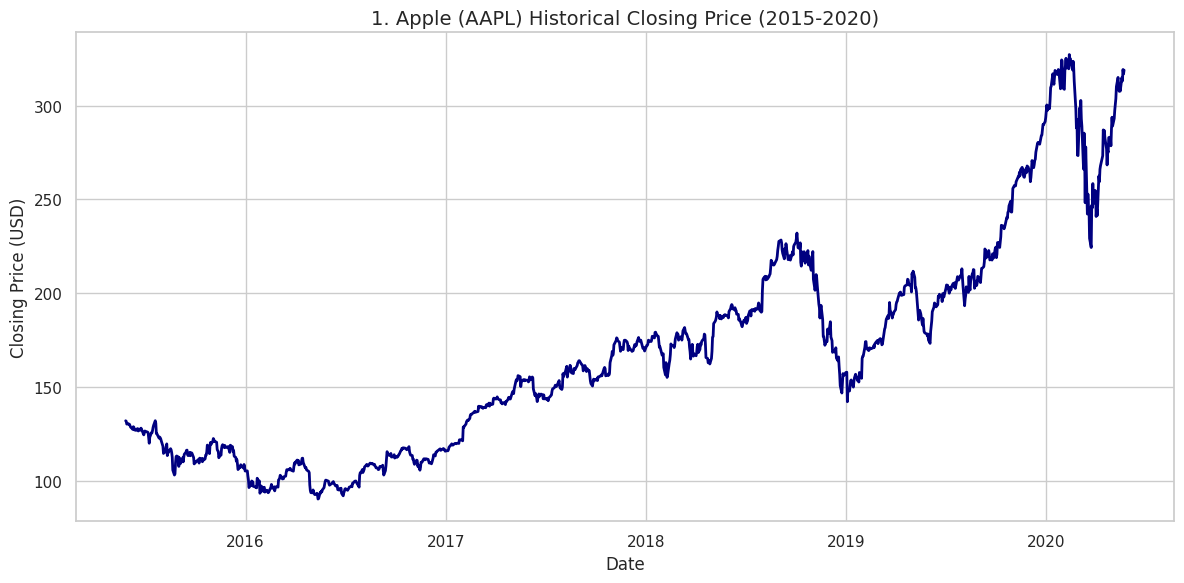

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], color='navy', lw=2)

plt.title('1. Apple (AAPL) Historical Closing Price (2015-2020)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.show()

Daily Trading Volume Over Time

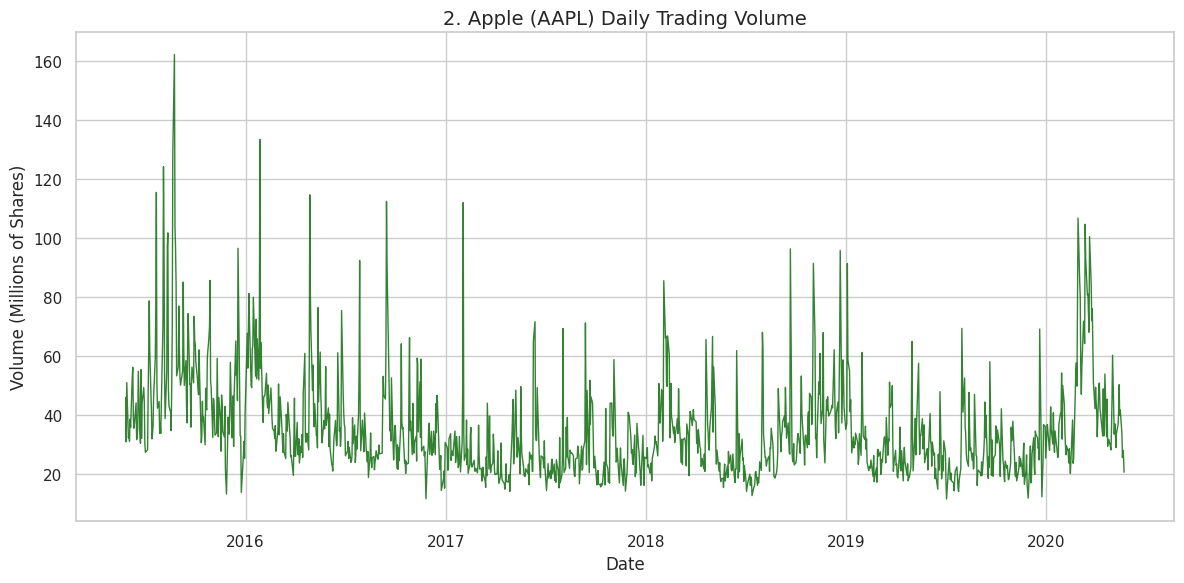

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['volume'] / 1e6, color='darkgreen', lw=1, alpha=0.8)

plt.title('2. Apple (AAPL) Daily Trading Volume', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume (Millions of Shares)')
plt.tight_layout()
plt.show()

Train/Test Split

In [8]:
features = ['open', 'high', 'low', 'volume']
X = df[features]
y = df['close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training data range: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing data range: {X_test.index.min().date()} to {X_test.index.max().date()}")

Training data range: 2015-05-27 to 2019-05-23
Testing data range: 2019-05-24 to 2020-05-22


Training the Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Performance:")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} USD")

Model Performance:
R-squared (R2) Score: 0.9972
Root Mean Squared Error (RMSE): 2.30 USD


Prediction vs Actuals

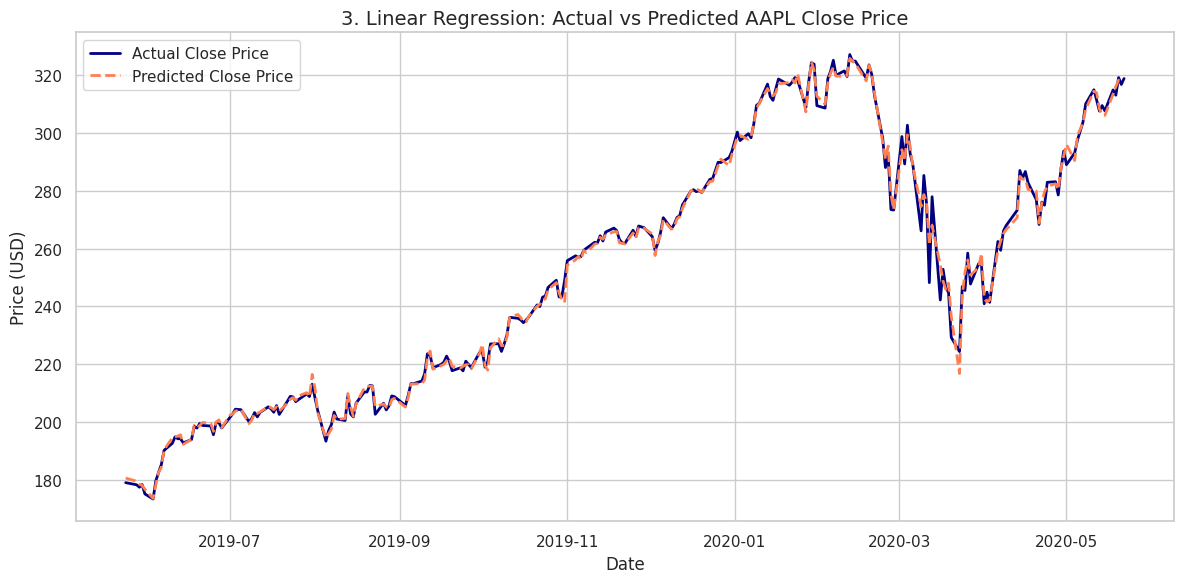

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(df.index[-len(y_test):], y_test, label='Actual Close Price', color='navy', lw=2)

plt.plot(df.index[-len(y_test):], y_pred, label='Predicted Close Price', color='coral', lw=2, linestyle='--')

plt.title('3. Linear Regression: Actual vs Predicted AAPL Close Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

Calculating Daily Returns

In [11]:
df['Daily_Return'] = df['close'].pct_change() * 100

df[['close', 'Daily_Return']].head()

,close,Daily_Return
date,,
2015-05-27,132.045,NaN
2015-05-28,131.780,-0.200689
2015-05-29,130.280,-1.138261
2015-06-01,130.535,0.195732
2015-06-02,129.960,-0.440495


Distribution of Daily Returns

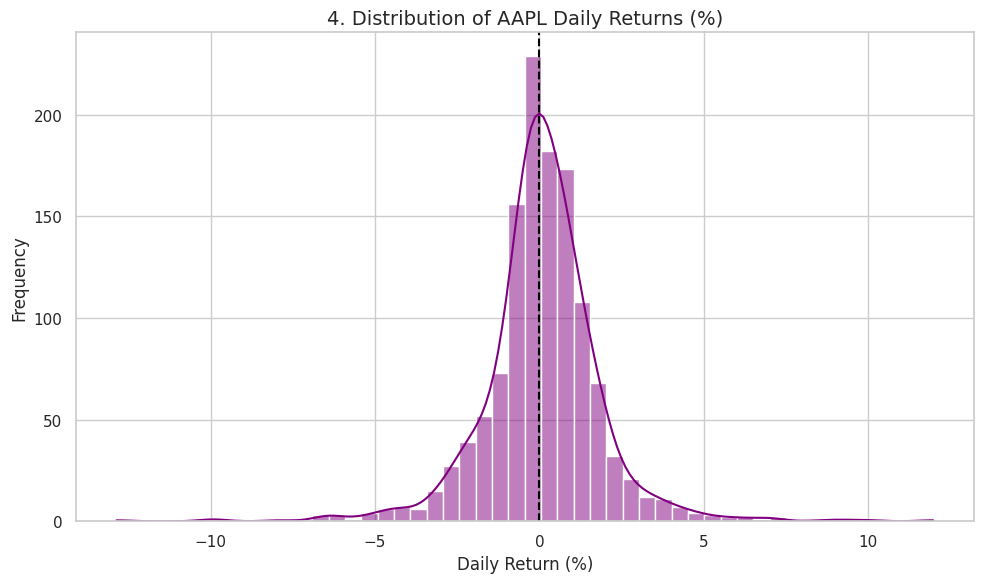

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')

plt.title('4. Distribution of AAPL Daily Returns (%)', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

plt.axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()